In [46]:
import sys
sys.path.append("C:/Users/siddh/Desktop/Graduate files/Research/mpemba_functions/")

import mpemba
import fokker_planck

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('default')

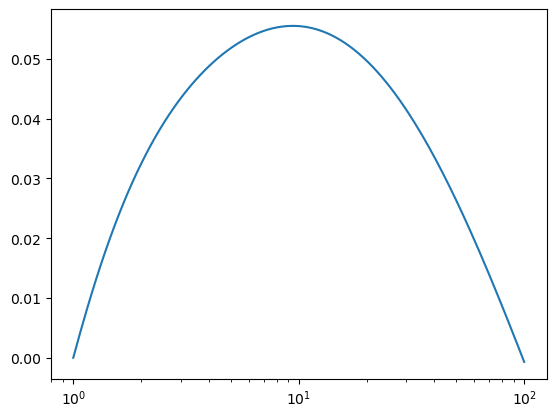

In [47]:
avinashian_potential.plot_a_2s(100)

100%|██████████| 9999/9999 [00:01<00:00, 5396.26it/s]


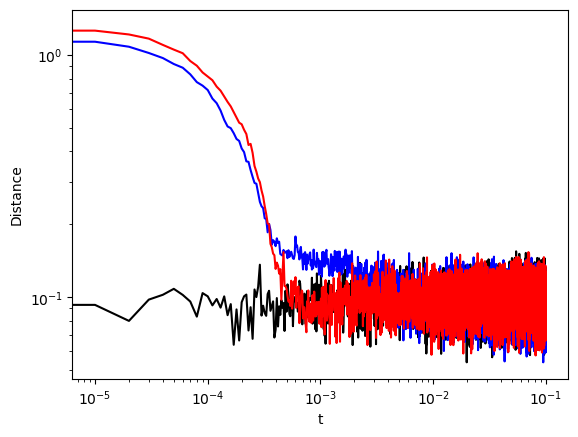

In [62]:
avinashian_potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(x_min=-1, x_max=3)
for N in [2000]:
    avinashian_ensemble_N = mpemba.construct_simulated_ensemble(avinashian_potential, k_BTs=[1000,100,1], num_particles=N)
    avinashian_ensemble_N.plot_distances()
    avinashian_ensemble_N.export_distances(f"avinashianDistances_{N}.csv")

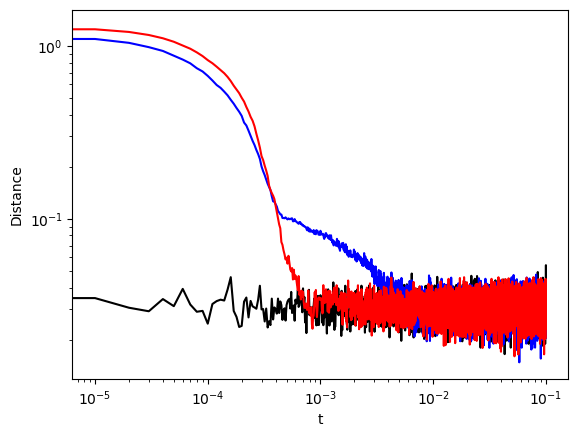

In [53]:
avinashian_ensemble_N.plot_distances()

In [17]:
mesh = avinashian_potential.mesh(500)
150*1e-6/(mesh[1]-mesh[0]) *avinashian_potential.grima_newman_discretisation(avinashian_potential.mesh(500))

array([[-0.01923149,  0.01165281,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.01923149, -0.0308843 ,  0.01165281, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.01923149, -0.0308843 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.0308843 ,
         0.01923149,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.01165281,
        -0.0308843 ,  0.01923149],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.01165281, -0.01923149]])

In [58]:
p_trajectories = fokker_planck.analytic_solution([1000,100], avinashian_potential, t_max=0.01, D=150, n_x=500, dt=2e-7, error_tolerance=4e-3)

100%|██████████| 2/2 [03:34<00:00, 107.29s/it]


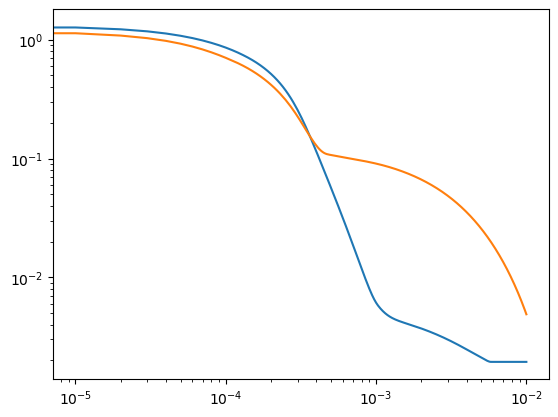

In [60]:
distances = fokker_planck.analytical_distances_to_boltzmann(p_trajectories, avinashian_potential)

times = np.arange(p_trajectories.shape[2])*1e-5
plt.loglog(times, distances.T)
df = pd.DataFrame(distances.T, columns=['h','w'], index=times)
df.to_csv("avinashianDistances_FPE.csv")